## Homework B05: Monks data, estimate the reciprocity in "likes" where each month named 3 likes
By Prabhakar Srivastava

In [1]:
import pandas as pd
import numpy as np
from numpy.random import default_rng
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt

In [2]:
# Random seed and plotting style
plt.style.use("statistical-rethinking-2023.mplstyle")

seed_ = sum(map(ord, "Monks and Reciprocity Homework B05 PyMC"))
random_seed = default_rng(seed_)

Download the data

In [3]:
filepath_str:str = "https://raw.githubusercontent.com/rmcelreath/rethinking/master/data/Monks.csv"

monks_df = pd.read_csv(filepath_str, sep=";")

In [4]:
# Redo the ids because python indexes from 0 and not 1!!
monks_df["dyad_id"] = monks_df["dyad_id"].sub(1)
monks_df["A_id"] = monks_df["A"].sub(1)
monks_df["B_id"] = monks_df["B"].sub(2)
monks_df.head()

,dyad_id,A,B,like_AB,like_BA,dislike_AB,dislike_BA,A_name,B_name,A_id,B_id
0,0,1,2,0,3,0,0,ROMUL,BONAVEN,0,0
1,1,1,3,3,3,0,0,ROMUL,AMBROSE,0,1
2,2,1,4,0,0,0,0,ROMUL,BERTH,0,2
3,3,1,5,0,0,0,0,ROMUL,PETER,0,3
4,4,1,6,0,0,0,0,ROMUL,LOUIS,0,4


In [5]:
monks_df["A_name"].unique()

<ArrowStringArray>
[  'ROMUL', 'BONAVEN', 'AMBROSE',   'BERTH',   'PETER',   'LOUIS',  'VICTOR',
    'WINF',    'JOHN',    'GREG',    'HUGH',    'BONI',    'MARK',  'ALBERT',
   'AMAND',   'BASIL',   'ELIAS']
Length: 17, dtype: str

In [6]:
print(monks_df.shape)

(153, 11)


The Model will be as follows (note the Homework says we can ignore dislikes and only need to consider receiving effects) <br>
Because the number of likes is fixed we only focus on recieving effects <br>
<center>  $G_{AB} \sim \text{Binomial}(p_{AB}, 3)$ </center>
<center> $p_{AB} = \text{invlogit}(\alpha + T_{AB} + R_B)$ (Note: A gives and B receives)</center> 
<center>  $G_{BA} \sim \text{Binomial}(p_{BA}, 3)$ </center>
<center> $p_{BA} = \text{invlogit}(\alpha + T_{BA} + R_A)$  (Note: B gives and A receives)</center>
<center> $\alpha \sim \text{Normal}(0, 1)$ </center>
<center> $R_{A,B} \sim \text{Normal}(0,1)$</center>
<center> $\begin{pmatrix} T_{AB} \\ T_{BA} \end{pmatrix} \sim \text{MVNormal}(\begin{bmatrix} 0 \\ 0 \end{bmatrix},
    \begin{bmatrix} \sigma^2 & \rho \sigma \\ \rho \sigma & \sigma^2 \end{bmatrix}) $ </center>
<center> $\rho \sim \text{LKJ}(2)$ </center>
<center> $\sigma \sim \text{Exponential}(1)$ </center>

In [7]:
# Build out COORDS for PyMC
COORDS = {"dyad": monks_df["dyad_id"].unique(),
          "A": monks_df["A_name"].unique(),
          "B": monks_df["B_name"].unique(),
          "obs": np.arange(len(monks_df)),
          "monk": ["A", "B"]
         }
NCORRELATED_FEATURES = 2

In [8]:
with pm.Model(coords=COORDS) as monks_dyads:

    # Data
    dyad_id = pm.Data("dyad_id", monks_df["dyad_id"].values.astype(int), dims="obs")
    A_id = pm.Data("A_id", monks_df["A_id"].values.astype(int), dims="obs")
    B_id = pm.Data("B_id", monks_df["B_id"].values.astype(int), dims="obs")

    # Observed
    like_AB_obs = pm.Data("like_AB_obs", monks_df["like_AB"].values.astype(int), dims="obs")
    like_BA_obs = pm.Data("like_BA_obs", monks_df["like_BA"].values.astype(int), dims="obs")

    # Priors
    α = pm.Normal("α", mu=0, sigma=1) # Intercept
    # Prior on Receiving effects
    R_A = pm.Normal("R_A",  mu=0, sigma=1, dims="A")
    R_B = pm.Normal("R_B", mu=0, sigma=1, dims="B")

    # Ties within Dyads:  Uncentered Parameterization
    chol_T, ρ_T, σ_T = pm.LKJCholeskyCov("chol", 
                                         eta=2, 
                                         n=NCORRELATED_FEATURES, 
                                         sd_dist=pm.Exponential.dist(1)
                                        ) # Has dims of monk
    # Normal
    Z = pm.Normal("Z", mu=0, sigma=1, dims=("dyad", "monk"))
    T = pm.Deterministic("T", (chol_T @ Z.T).T, dims=("dyad", "monk"))

    p_AB = pm.Deterministic("p_AB", pm.math.invlogit(α + T[dyad_id, 0] + R_B[B_id]), dims="obs") # A gives and B receives
    p_BA = pm.Deterministic("p_BA", pm.math.invlogit(α + T[dyad_id, 1] + R_A[A_id]), dims="obs") # B gives and A recieves

    # Likelihood
    like_AB = pm.Binomial("like_AB", n=3, p=p_AB, observed=like_AB_obs, dims="obs")
    like_BA = pm.Binomial("like_BA", n=3, p=p_BA, observed=like_BA_obs, dims="obs")

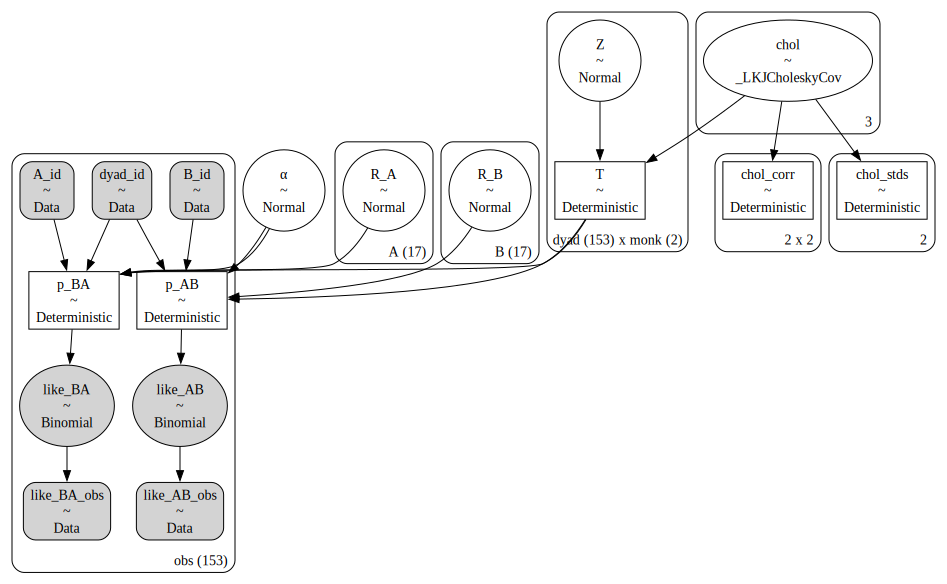

In [9]:
pm.model_to_graphviz(monks_dyads)

Inference

In [10]:
with monks_dyads:
    idata = pm.sample(random_seed=random_seed, target_accept=0.85)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [α, R_A, R_B, chol, Z]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 8 seconds.


In [11]:
az.summary(idata, round_to=2, var_names=["~chol_corr",
                                         "~R_A", 
                                         "~R_B", 
                                         "~p_AB", 
                                         "~p_BA", 
                                         "~Z",
                                         "~T"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
α,-4.05,0.43,-4.93,-3.29,0.01,0.01,2679.12,2731.05,1.00
chol[0],2.72,0.43,1.98,3.54,0.01,0.01,2132.06,2831.09,1.00
chol[1],2.64,0.56,1.60,3.69,0.02,0.01,1259.00,1817.02,1.01
chol[2],2.60,0.57,1.51,3.64,0.02,0.01,1381.92,2514.61,1.00
chol_stds[0],2.72,0.43,1.98,3.54,0.01,0.01,2132.06,2831.09,1.00
chol_stds[1],3.75,0.55,2.79,4.83,0.01,0.01,1684.08,2679.44,1.00


In [12]:
az.summary(idata, round_to=2, var_names=["chol_corr"])

/Users/prabh/miniconda3/envs/bap3/lib/python3.11/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/Users/prabh/miniconda3/envs/bap3/lib/python3.11/site-packages/arviz/stats/diagnostics.py:991: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
"chol_corr[0, 0]",1.0,0.00,1.00,1.0,0.0,NaN,4000.00,4000.00,NaN
"chol_corr[0, 1]",0.7,0.11,0.51,0.9,0.0,0.0,1143.30,1683.10,1.0
"chol_corr[1, 0]",0.7,0.11,0.51,0.9,0.0,0.0,1143.30,1683.10,1.0
"chol_corr[1, 1]",1.0,0.00,1.00,1.0,0.0,0.0,4059.25,3981.78,1.0


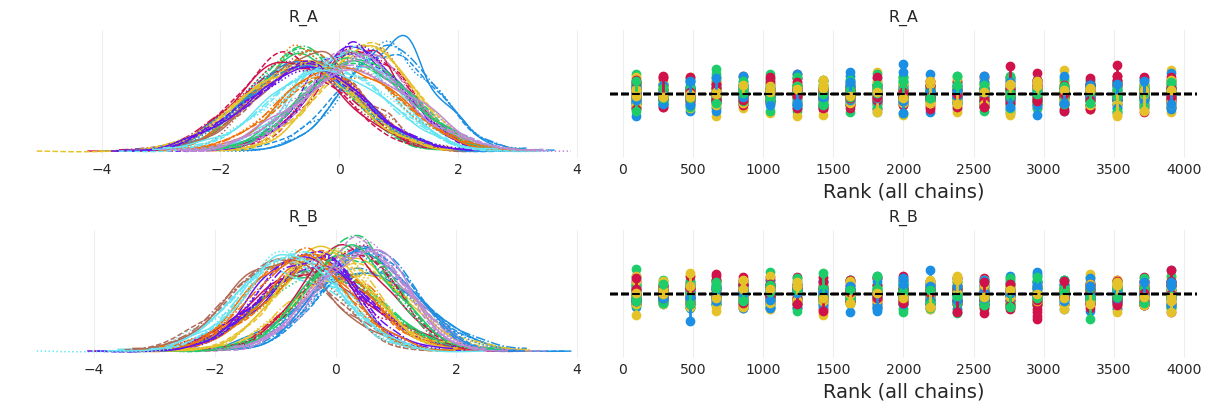

In [13]:
az.plot_trace(idata, var_names=["R_A", "R_B"], kind="rank_vlines")
plt.show()

Plot the distribution of the correlation of Ties within Dyads

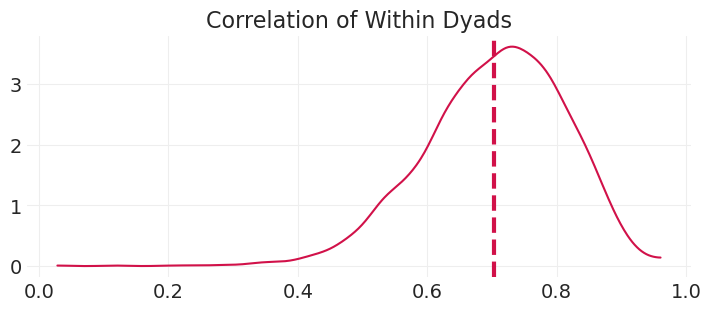

In [14]:
_, ax = plt.subplots(figsize=(7., 3.))
az.plot_dist(
    idata
    .posterior["chol_corr"]
    .sel(chol_corr_dim_0 = 0, chol_corr_dim_1 = 1) # This is the [1, 2] = [2, 1] element of the correlation matrix
    ,ax = ax
)
ax.axvline(
    idata
    .posterior["chol_corr"]
    .sel(chol_corr_dim_0=0, chol_corr_dim_1=1)
    .mean(dim=("chain", "draw")),
    ls="--",
    lw=3.
)
ax.set_title("Correlation of Within Dyads")
plt.show()

Plot "Household" (Monastery) ties

In [15]:
T_AB = idata.posterior["T"].sel(monk="A").mean(dim=("chain", "draw")).values # Ties A -> B
T_BA = idata.posterior["T"].sel(monk="B").mean(dim=("chain", "draw")).values # Ties B -> A

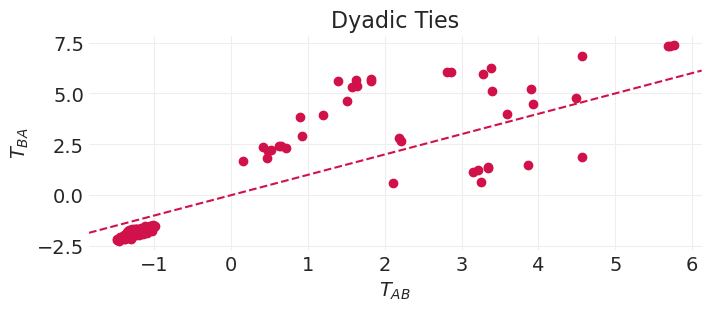

In [16]:
_, ax = plt.subplots(figsize=(7., 3.))
ax.scatter(T_AB, T_BA)
ax.axline((0,0), slope=1., linestyle="--")
ax.set_xlabel(r"$T_{AB}$")
ax.set_ylabel(r"$T_{BA}$")
ax.set_title("Dyadic Ties")
plt.show()

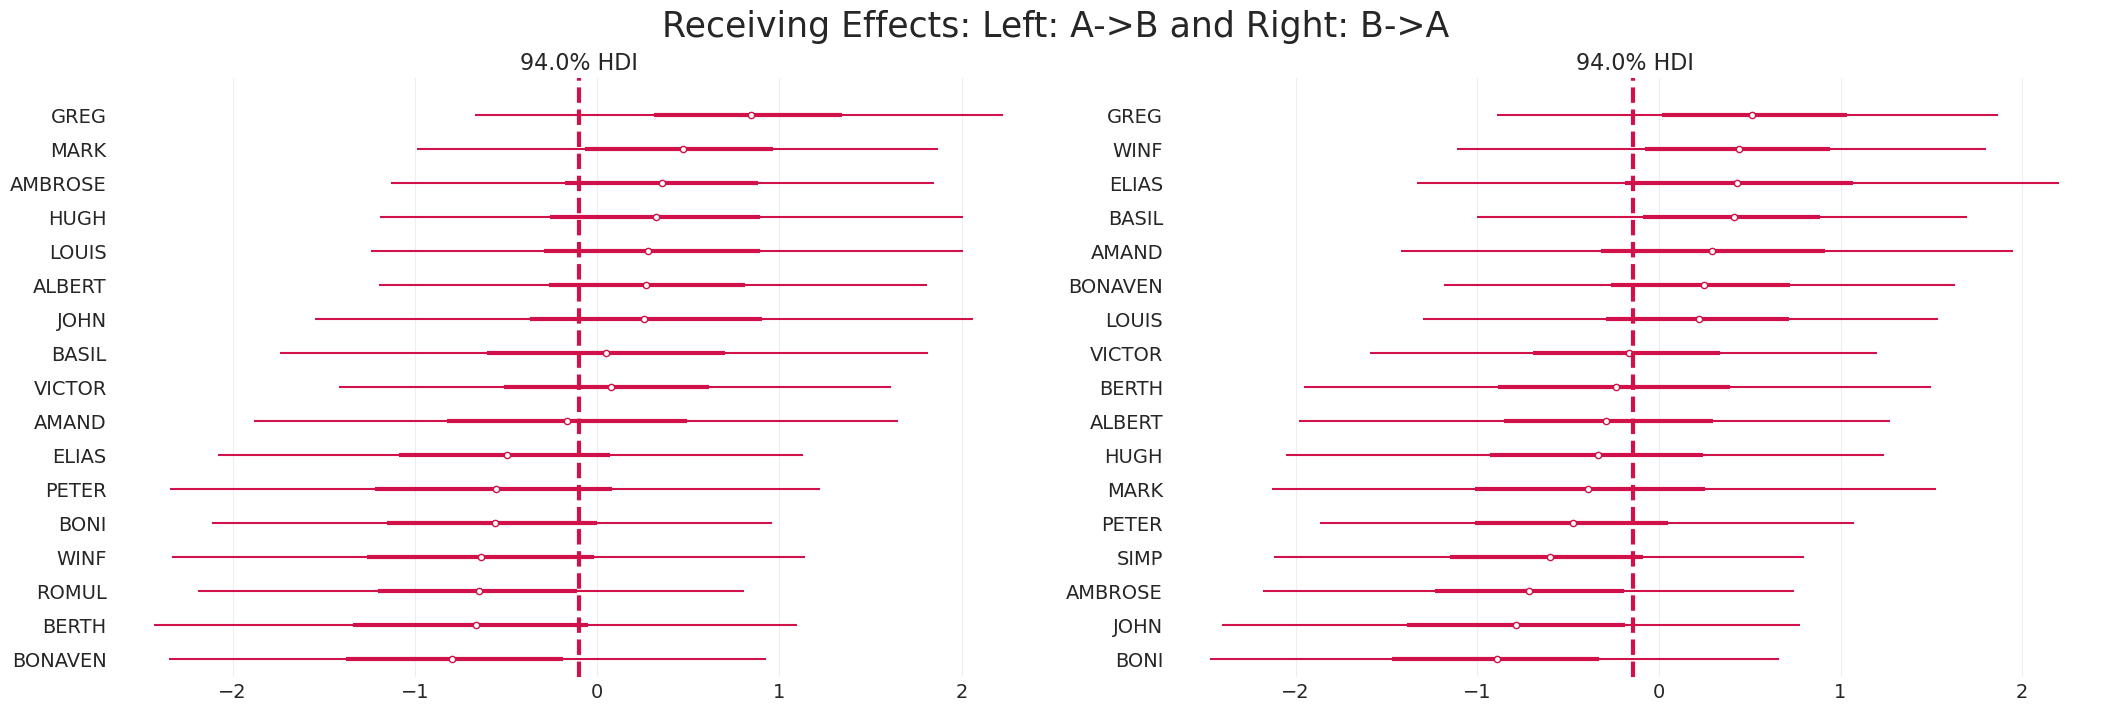

In [17]:
_, axes = plt.subplots(nrows=1, ncols=2, figsize=(21., 7.))

# A -> B: B is receiving
ids_A = np.argsort(idata.posterior["R_A"].mean(dim=("chain", "draw")))
az.plot_forest(
    idata.posterior["R_A"].values[:, :, ids_A[::-1]],
    combined=True,
    ax=axes[0]
)
axes[0].axvline(idata.posterior["R_A"].mean(dim=("chain", "draw", "A")), ls="--", lw=3)
axes[0].set_yticklabels(COORDS["A"][ids_A[::-1]])

# B -> A: A is receiving
ids_B = np.argsort(idata.posterior["R_B"].mean(dim=("chain", "draw")))
az.plot_forest(
    idata.posterior["R_B"].values[:, :, ids_B[::-1]],
    combined=True,
    ax=axes[1]
)
axes[1].axvline(idata.posterior["R_B"].mean(dim=("chain", "draw", "B")), ls="--", lw=3)
axes[1].set_yticklabels(COORDS["B"][ids_B[::-1]])
plt.suptitle("Receiving Effects: Left: A->B and Right: B->A", size=25)
plt.show()